Created by Sanish Bhochhibhoya (03/08/2025)

In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [2]:
import geomodgen2d
import geomodgen2d.discretized_interfaces2d as discretized_interfaces2d
from geomodgen2d.discretized_domain2d import DiscretizedDomain2D
import geomodgen2d.general_functions as f
import numpy as np
import geomodgen2d.lithological_domain2d as lithological_domain2d


In [3]:
# LithologicalDomain2D UnitTests
importlib.reload(lithological_domain2d)
setting = 6

remesh_interp_method = 'nearest'
boundary_dh = 0.25
obs_dhx = 0.2
obs_dhz = 0.1

if setting == 1:
    boundary_type = 1
    to_npz = r'./test/data/lit_domain_test_B1_nearest.npz'
elif setting == 2:
    boundary_type = 2
    to_npz = r'./test/data/lit_domain_test_B2_nearest.npz'
elif setting == 3:
    boundary_type = 3
    to_npz = r'./test/data/lit_domain_test_B3_nearest.npz'
elif setting == 4:
    boundary_type = 1
    remesh_interp_method = 'linear'
    to_npz = r'./test/data/lit_domain_test_B1_linear.npz'
elif setting == 5:
    boundary_type = 2
    remesh_interp_method = 'linear'
    to_npz = r'./test/data/lit_domain_test_B2_linear.npz'
elif setting == 6:
    boundary_type = 3
    remesh_interp_method = 'linear'
    to_npz = r'./test/data/lit_domain_test_B3_linear.npz'

to_save = {}
gwt_depth = 1.8


In [ ]:
domain2D = geomodgen2d.discretized_domain2d.DiscretizedDomain2D(
    span_x=5, span_z=4, dx=1, dz=1
)
boundary2D = discretized_interfaces2d.DiscretizedInterfaces2D(
    domain=domain2D, n_soil_layers=4, generate_surface=True, rng=np.random.default_rng(2), remesh_interp_method=remesh_interp_method)

boundary = [[0.6, 1.57, 3.99, 3.99],
        [0.2, 1.17, 3.59, 3.59],
        [0, 1.41, 3.5, 3.67],
        [0, 1.85, 3.1, 3.95],
        [1, 3.29, 3.7, 5.23],
        [1.2, 3.93, 3.93, 5.71],
        [0.5, 3.23, 3.23, 5.01]]

boundary2D.set_interfaces_matrix(boundary)
boundary2D_hz, _ = boundary2D.get_surface_and_subsurface_interfaces(True)
boundary2D_hz2, _ = boundary2D.get_surface_and_subsurface_interfaces(False)

obs2D1 = geomodgen2d.obstruction2d.Obstruction2D(dl=0.5, ref_xz_symbolic=('0', 0), snap_to_dl=False)  #Should be same as above
obs2D1.circle_2d(2, 1)

obs2D2 = geomodgen2d.obstruction2d.Obstruction2D(dl=0.5, ref_xz_symbolic=('c', 0), snap_to_dl=False)  #Should be same as above
obs2D2.rectangle_2d(3, 2, 2)


In [5]:
boundary2D.remesh_interp_method

'linear'

F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\discretized_interfaces2d.py:386: UserWarning: Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.
  warnings.warn("Overlapping interfaces found after remesh; Applied default erosion processing at the edges to correct them. This should not affect most models.")


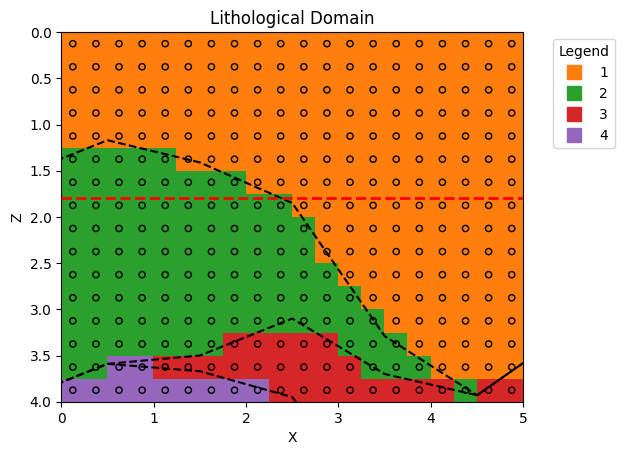

In [6]:
if boundary_type==1:
    boundary = boundary2D
elif boundary_type==2:
    boundary = boundary2D_hz
else:
    boundary = boundary2D_hz2


geomodgen2d.lithological_domain2d.GlobalSoilInterfaceConfig.reset()
geomodgen2d.lithological_domain2d.GlobalSoilInterfaceConfig.set_soil_interface(boundary)


name = 'lit_domain1'

domain2D_lit = geomodgen2d.discretized_domain2d.DiscretizedDomain2D(
    span_x=5, span_z=4, dx=boundary_dh, dz=boundary_dh
)

lit = lithological_domain2d.LithologicalDomain2D(domain2D_lit, gwt_depth, name)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot(discrete_point_size = 20, plot_interfaces=True)
# boundary.io.print()

to_save['lit_domain1_matrix'] = lit.lithological_matrix

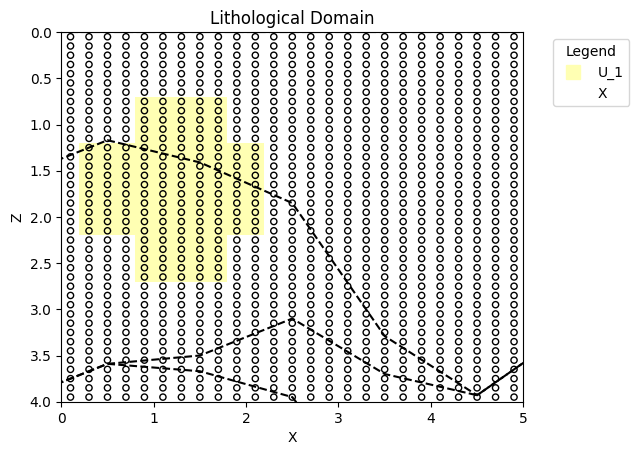

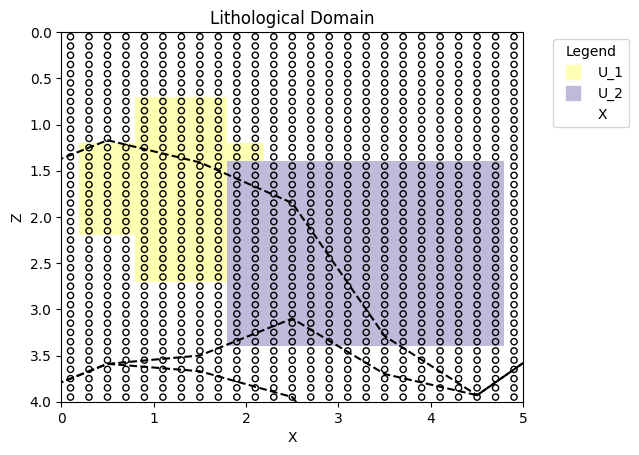

In [7]:
domain2D_obs = geomodgen2d.discretized_domain2d.DiscretizedDomain2D(
    span_x=5, span_z=4, dx=obs_dhx, dz=obs_dhz
)

obs1_ref_point = [0.25, .74] #edge cases... minus .01 to the left 
obs2_ref_point = [3.38,1.44]

obs_lit = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D_obs, 'obst')
# obs_lit.add_obstruction2D(obs2D1, [1.4,1.7], 'U')
obs_lit.add_obstruction2D(obs2D1, obs1_ref_point, 'U')
# obs2D2.plot(discrete_point_size = 20)
obs_lit.plot(discrete_point_size = 20, plot_interfaces=True)

obs_lit.add_obstruction2D(obs2D2, obs2_ref_point, 'U')
obs_lit.plot(discrete_point_size = 20, plot_interfaces=True)

to_save['obs_lit_matrix'] = obs_lit.lithological_matrix

F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator\geomodgen2d\lithological_domain2d.py:315: UserWarning: Looks like the lit domain has been remeshed with linear after creation.
  warnings.warn("Looks like the lit domain has been remeshed with linear after creation.")


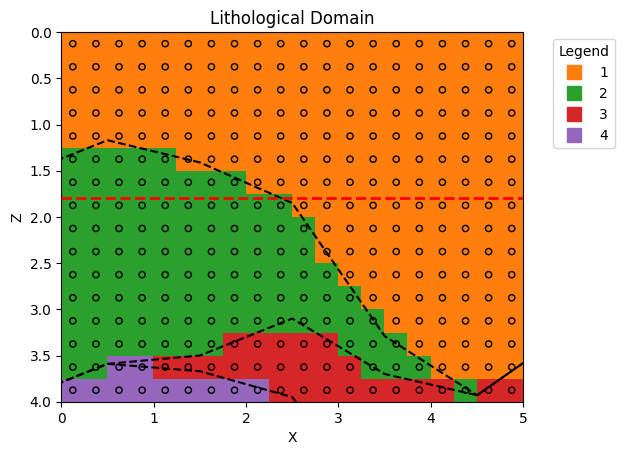

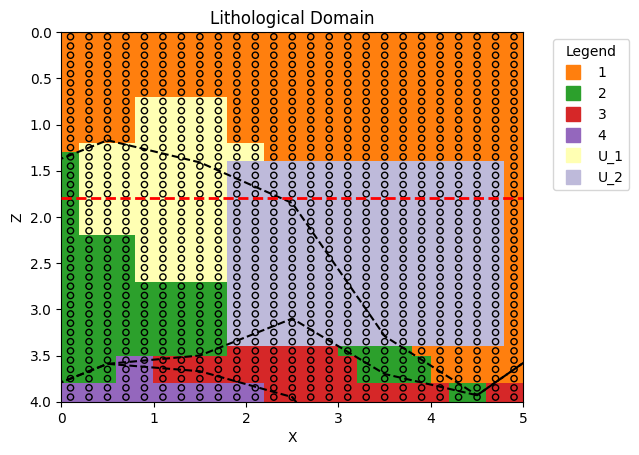

In [8]:
merged_lit = lit.return_merged_lithological_domain([obs_lit])
lit.plot(discrete_point_size = 20, plot_interfaces=True)
merged_lit.plot(discrete_point_size = 20, plot_interfaces=True)

to_save['merged_lit_matrix'] = merged_lit.lithological_matrix

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

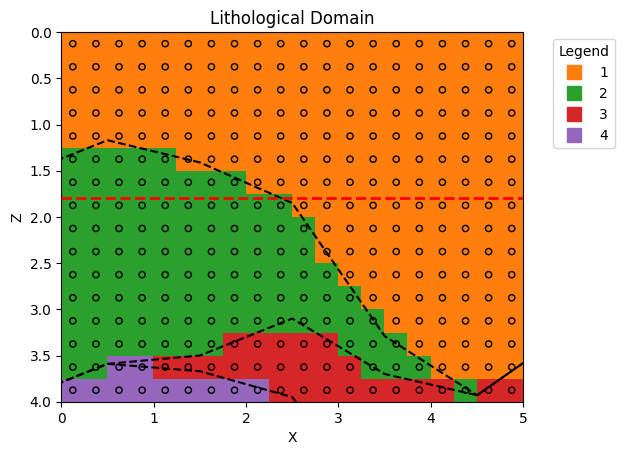

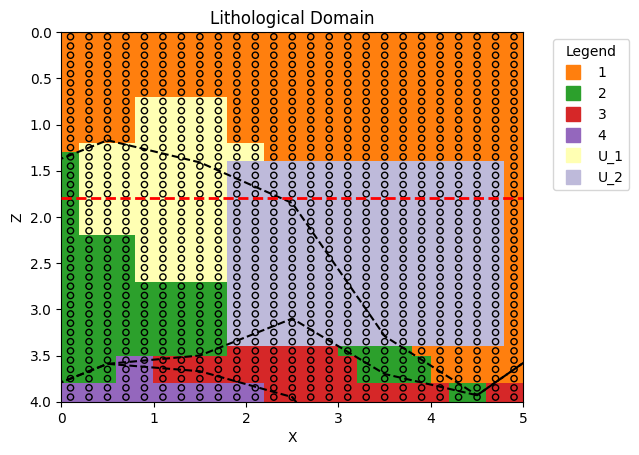

In [9]:
### TO THINK: WHY INTERFACE PATTERN CHANGED ON REMESHING..
### I THINK THIS IS NOT AN ISSUE IF WE DO DOMAIN DISCRETIZATION ONLY NO INTERFACE DISCRETIZATION. BUT DO CHECK.

lit = lithological_domain2d.LithologicalDomain2D(domain2D_lit,  gwt_depth, name)

obs_lit1 = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D_obs, 'obst')
obs_lit1.add_obstruction2D(obs2D1, obs1_ref_point, 'U')

obs_lit2 = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D_obs, 'obst')
obs_lit2.add_obstruction2D(obs2D2, obs2_ref_point, 'U')

merged_lit = lit.return_merged_lithological_domain([obs_lit1, obs_lit2])
lit.plot(discrete_point_size = 20, plot_interfaces=True)
merged_lit.plot(discrete_point_size = 20, plot_interfaces=True)

In [10]:
np.savez_compressed(to_npz, **to_save)

In [11]:
# data = np.load(to_npz)
# loaded_dict = {key: data[key] for key in data.files}

# for key in to_save.keys():
#     print(key)
#     a = to_save[key]
#     b = loaded_dict[key]

#     # string or object arrays → direct equality
#     if a.dtype.kind in {"U", "S", "O"}:
#         assert np.array_equal(a, b)
#     else:
#         assert np.isclose(a,b).all()